# Crystal Identification
## Clustering Analysis & Digital Dark Field Images

### Import packages and load data

In [2]:
from sklearn.cluster import DBSCAN
from colorsys import hsv_to_rgb
import numpy as np
import matplotlib.pyplot as plt
import string

In [3]:
# Load Data
PeaksArray = np.load('data/PeaksArray_SmallRange.npy')
COM_Values = np.load('data/COM_Values.npy')
db1labels = np.load('data/db1labels.npy')
db2labels = np.load('data/db2labels.npy')

### Digital Dark Field Function

In [4]:
def VirtualImage(Data, Label, Index, savefig = True, figax = None):
    '''
    Function which produces the Digital Dark Field Image of a selected cluster.

    Data types:
    Data: numpy array
    Label: numpy array
        this corresponds to the clustering type, so for DBSCAN use db.labels_
        
    Index: Int
        select the index of the cluster
    figax: tuple, None
        (fig, ax)
    
    Return: 
    '''
    Cluster = Data[np.where(Label == Index)]

    Rxc = Cluster[:, 3]
    Ryc = Cluster[:, 4]

    # Finding max dimensions of Rx, Ry
    Rxmax, Rymax = Data[:,3].max().astype('int')+1, Data[:,4].max().astype('int')+1
    
    # Create image 
    image = np.zeros(shape=(Rxmax,Rymax))
    image[Rxc.astype('int'), Ryc.astype('int')]  = Cluster[:,2]

    # Plot
    if figax != None:
        fig, ax = figax
    else:
        fig, ax = plt.subplots(figsize=[7,7])

    ax.imshow(image)
      
    ax.set_xlabel('Ry')
    ax.set_ylabel('Rx')

    plt.show()
         
    if savefig:
        fig.savefig('DigitalDarkFieldImage')

### Transfer level 1 and level 2 cluster labels into the full data array 

In [5]:
# Identify the unique labels in level 2
L2Unique = np.unique(db2labels) 
L2numlabs = np.append(L2Unique[L2Unique != -1], -1) # set last number to be -1

# Insert alphabetical letters
L2letterlabs = string.ascii_uppercase[:L2numlabs.shape[0]]

# Create dict
labs1 = dict(list(zip(L2numlabs, L2letterlabs))) # numbers to letters
labs2 = dict(list(zip(L2letterlabs, L2numlabs))) # letters to numbers

# Ensure noise is Z = -1
labs1[-1] = 'Z'
labs2['Z'] = -1

# Add level 1 labels to data array
Dataset = np.column_stack((PeaksArray, db1labels))

# Indexing to ensure correct length of lvl2 labels, also maps lvl1 clusters to lvl2 clusters
indexing = db2labels[db1labels]

# Source - https://stackoverflow.com/a/57058920
# Posted by yatu
# Retrieved 2026-03-15, License - CC BY-SA 4.0
lvl2 = np.vectorize(labs1.get)(indexing.astype(int))

# Add level 2 labels to data array
FullDataset = np.column_stack((Dataset, lvl2))

# New Data Array Columns
Qx = FullDataset[:,0]
Qy = FullDataset[:,1]
I = FullDataset[:,2]
Rx = FullDataset[:,3]
Ry = FullDataset[:,4] 
Qr = FullDataset[:,5]
Qphi = FullDataset[:,6]
Clusters1 = FullDataset[:,7]
Clusters2 = FullDataset[:,8] 

### Digital dark field images of individual crystals 

**All crystals from COM clustering**

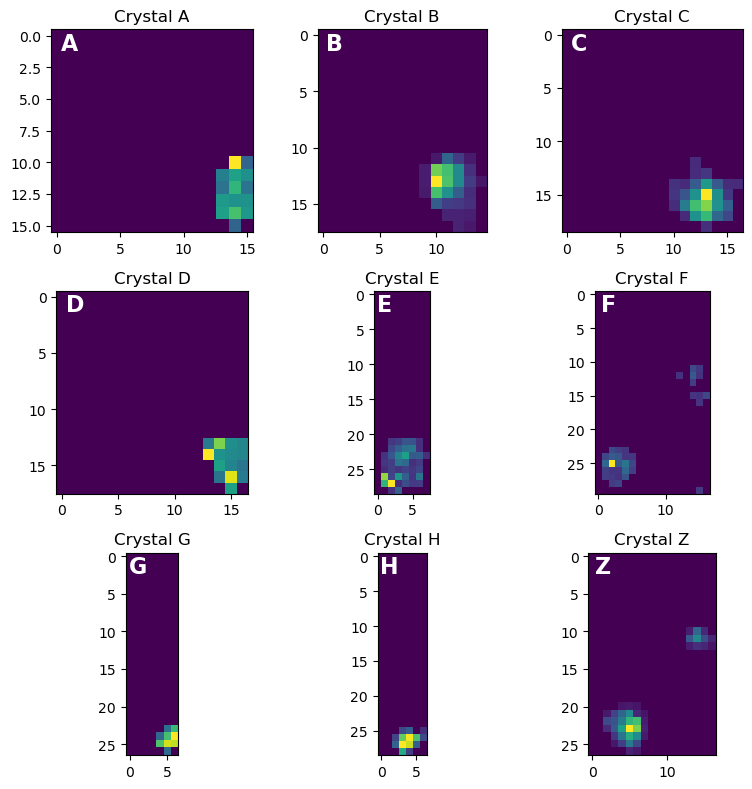

In [15]:
# Subplots
fig, axes = plt.subplots(nrows=(3), ncols=(3), figsize=[8,8])
axes = axes.flatten()

for i, j in enumerate(np.unique(lvl2)):
    
    CL = FullDataset[:, 8] == j
    Vectors = FullDataset[CL]
    CrystalData = Vectors[:,0:8].astype(float)

    Rxc = CrystalData[:,3]
    Ryc = CrystalData[:,4]

    Rxmax, Rymax = CrystalData[:,3].max().astype('int')+1, CrystalData[:,4].max().astype('int')+1

    image = np.zeros((Rxmax, Rymax))
    image[Rxc.astype('int'), Ryc.astype('int')] = CrystalData[:,2]
    
    axes[i].imshow(image)
    axes[i].set_title('Crystal {0}'.format(j))
    axes[i].text(0.05, 0.9, j, transform=axes[i].transAxes,fontsize=16, color='white', weight='bold')
    fig.tight_layout()

In [7]:
# two samples, not clustering seperating quite right

In [8]:
# select the centres of the clusters and plot in the diffraction space

In [9]:
# find COM for each cluster
def COM_X(m,x):
    '''
    Calculates COM for x-coordinate.

    Data types:
    m: int or numpy array
    x: numpy array
    '''
    return (np.sum(m * x)) / np.sum(m)

def COM_Y(m,y):
    '''
    Calculates COM for y-coordinate.

    Data types:
    m: int or numpy array
    y: numpy array
    '''
    return (np.sum(m * y)) / np.sum(m)

def Cluster_COM(Data, Range, label, Weight=True):
    '''
    Calculates COM for every cluster in a clustering graph.
    
    Data types:
    Data: numpy array
    Range: numpy array
    label: numpy array
    Weight: bool
        if True, applies pixel weighting to the centre of masses

    '''
    COM_Values = []

    # loop over all clusters
    for p in Range:
        Cluster = Data[np.where(label == p)]

        if Weight:
            # COM weighting
            COM_Values.append((
                COM_X(Cluster[:,2], Cluster[:,3]),
                COM_Y(Cluster[:,2], Cluster[:,4])
            ))

        else:
            #COM no weighting
            COM_Values.append((
                COM_X(1, Cluster[:,3]),
                COM_Y(1, Cluster[:,4])
            ))
            
    return COM_Values

In [10]:
# Data B
CL = FullDataset[:, 8] == 'B'
Vectors = FullDataset[CL]
CrystalData = Vectors[:,0:8].astype(float)

In [11]:
#Cluster_COM(CrystalData, db2labels, label, Weight=True)

**Select individual clusters**

In [12]:
def IndividualCrystal(Letter): 

    # Example Select Crystal Label (CL)
    CL = FullDataset[:, 8] == Letter

    # All diffraction vectors associated with Crystal A 
    Vectors = FullDataset[CL]

    # Change values into floats
    # this is the dataset with all the clusters contained in 'A'
    CrystalData = Vectors[:,0:8].astype(float)

    # Select Rx, Ry components of A
    Rxc = CrystalData[:,3]
    Ryc = CrystalData[:,4]

    # Finding max dimensions of Rx, Ry
    Rxmax, Rymax = CrystalData[:,3].max().astype('int')+1, CrystalData[:,4].max().astype('int')+1

    # Create image 
    image = np.zeros(shape=(Rxmax,Rymax))
    image[Rxc.astype('int'), Ryc.astype('int')]  = CrystalData[:,2]

    # Plot
    fig, ax = plt.subplots(figsize=[6,6])

    ax.imshow(image)
    ax.set_title('Crystal {0}'.format(Letter))
    ax.set_xlabel('Ry')
    ax.set_ylabel('Rx')

    plt.show()

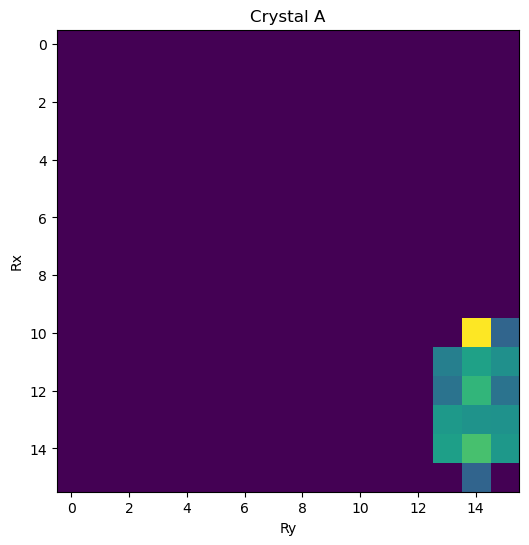

In [13]:
IndividualCrystal('A')

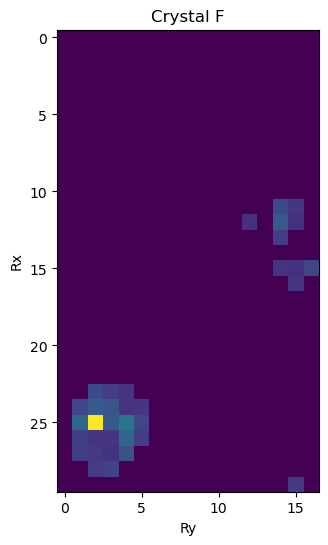

In [14]:
IndividualCrystal('F')

## Clustering on (Qx, Qy) for Crystal A Example

In [12]:
# Data A 
CL = FullDataset[:, 8] == 'A'
Vectors = FullDataset[CL]
CrystalData = Vectors[:,0:8].astype(float)

# Clustering on (Qx, Qy) for Crystal A
db3 = DBSCAN(eps=0.4, min_samples=1).fit(CrystalData[:,[0, 1, 3, 4]]) 

# Colour Scheme
colours = []
r = db3.labels_.max()+1
d = 5
for n in range(r):
    h, v = int(n/d), n%d 
    H = h/(r/d)
    V = (4+v)/8
    S = 1
    c = hsv_to_rgb(H,S,V)
    colours += [c] 

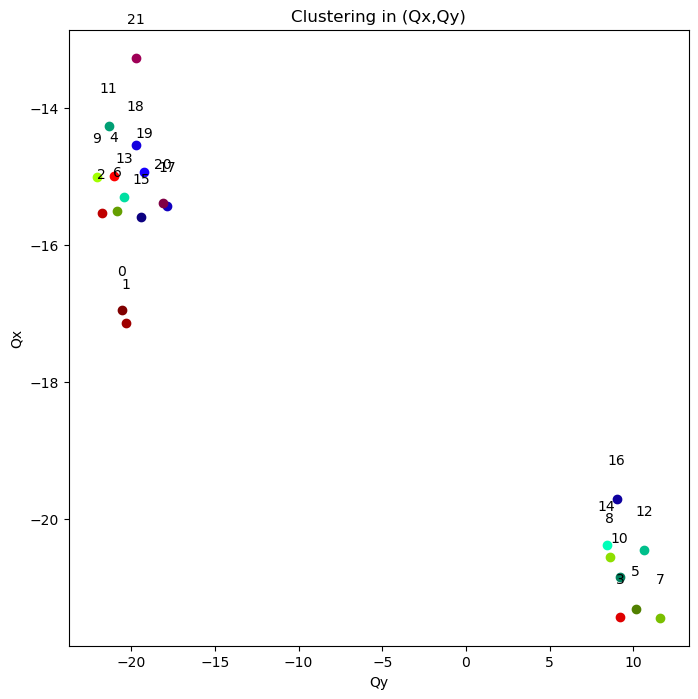

In [13]:
# Apply DBScan
plt.figure(figsize=[8,8])
plt.title('Clustering in (Qx,Qy)')

for i in range(r):   
    Cluster = CrystalData[np.where(db3.labels_ == i)]
    scatter = plt.scatter(Cluster[:, 1], Cluster[:, 0], color = colours[i], label = i)  
    
    for n in range(0,Cluster.shape[0],4500): # number of iterations 
        plt.text(
            Cluster[n, 1], 
            Cluster[n, 0]+0.5, 
            int(i),
            horizontalalignment='center'
        )

plt.xlabel('Qy')
plt.ylabel('Qx')
plt.show()

**Compare two crystals**